# Module 2: Exploratory Data Analysis (EDA)

**Goal:** Generate key charts and to be saved as PNG to `outputs/`


## Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from sqlalchemy import create_engine
import os

engine = create_engine('sqlite:///../ipl.db')
os.makedirs('../outputs', exist_ok=True) 

sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# IPL Brand Colors
IPL_BLUE = '#1B3D6F'
IPL_ORANGE = '#E8820C'
IPL_LIGHT = '#2E6DA4'

print('Setup complete. Engine connected to ipl.db')

Setup complete. Engine connected to ipl.db


## Chart 1 — Season-wise Total Runs (Line Chart) — CORE

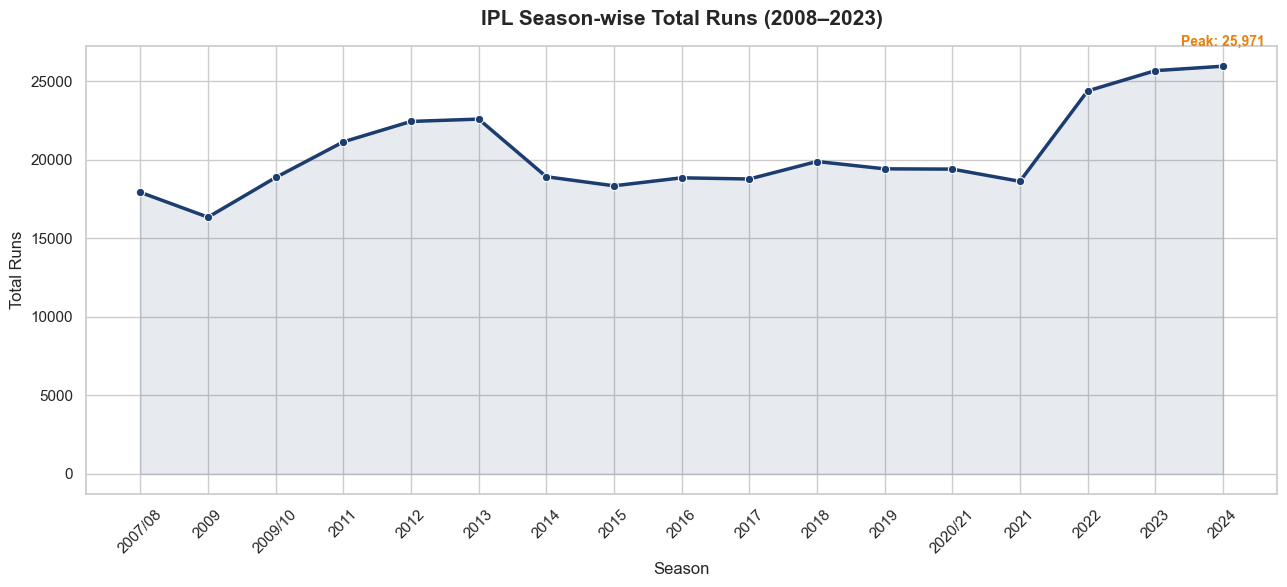

Chart 1 saved: chart1_season_runs.png


In [2]:
q = '''
SELECT m.season, SUM(d.total_runs) AS total_runs, COUNT(DISTINCT d.match_id) AS matches
FROM deliveries d JOIN matches m ON d.match_id = m.match_id
GROUP BY m.season
ORDER BY m.season
'''
df1 = pd.read_sql(q, engine)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=df1, x='season', y='total_runs', marker='o',
             color=IPL_BLUE, linewidth=2.5, ax=ax)
ax.fill_between(df1['season'], df1['total_runs'], alpha=0.1, color=IPL_BLUE)

# Annotate peak
peak = df1.loc[df1['total_runs'].idxmax()]
ax.annotate(f"Peak: {int(peak['total_runs']):,}",
            xy=(peak['season'], peak['total_runs']),
            xytext=(0, 15), textcoords='offset points',
            ha='center', fontsize=10, color=IPL_ORANGE, fontweight='bold')

ax.set_title('IPL Season-wise Total Runs (2008–2023)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Total Runs', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/chart1_season_runs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved: chart1_season_runs.png')

## Chart 2 — Top 10 Batsmen (Horizontal Bar) — CORE

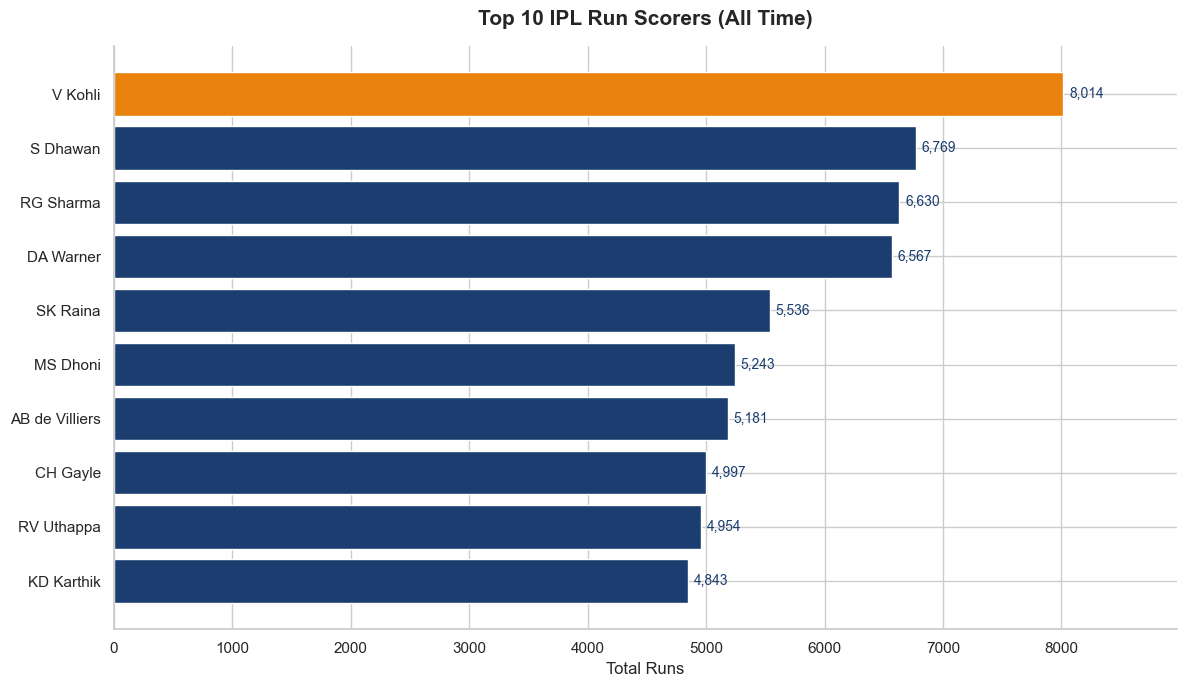

Chart 2 saved: chart2_top_batsmen.png


In [3]:
q = '''
SELECT batter, 
       SUM(batsman_runs) AS runs,
       ROUND(SUM(batsman_runs)*100.0/COUNT(*), 1) AS strike_rate
FROM deliveries
GROUP BY batter
ORDER BY runs DESC
LIMIT 10
'''

df2 = pd.read_sql(q, engine)

fig, ax = plt.subplots(figsize=(12, 7))

colors = [IPL_BLUE if i > 0 else IPL_ORANGE for i in range(len(df2))]
bars = ax.barh(df2['batter'], df2['runs'], color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, df2['runs']):
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f'{int(val):,}',
            va='center',
            fontsize=10,
            color=IPL_BLUE)

ax.invert_yaxis()
ax.set_title('Top 10 IPL Run Scorers (All Time)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Runs', fontsize=12)
ax.set_xlim(0, df2['runs'].max() * 1.12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/chart2_top_batsmen.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart 2 saved: chart2_top_batsmen.png')

## Chart 3 — Wicket Type Distribution (Donut Chart) — CORE

In [4]:
q = '''
SELECT dismissal_kind, COUNT(*) AS cnt
FROM deliveries
WHERE dismissal_kind IS NOT NULL AND dismissal_kind != ''
GROUP BY dismissal_kind
ORDER BY cnt DESC
'''
df3 = pd.read_sql(q, engine)

fig = px.pie(df3, names='dismissal_kind', values='cnt', hole=0.45,
             title='Wicket Type Distribution (All IPL Seasons)',
             color_discrete_sequence=px.colors.sequential.Blues_r)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(
    title_font_size=16,
    title_x=0.5,
    legend_title='Dismissal Type'
)
fig.write_image('../outputs/chart3_wicket_types.png', width=900, height=600)
fig.show()
print('Chart 3 saved: chart3_wicket_types.png')

Chart 3 saved: chart3_wicket_types.png


## Chart 4 — Toss Impact Heatmap — CORE

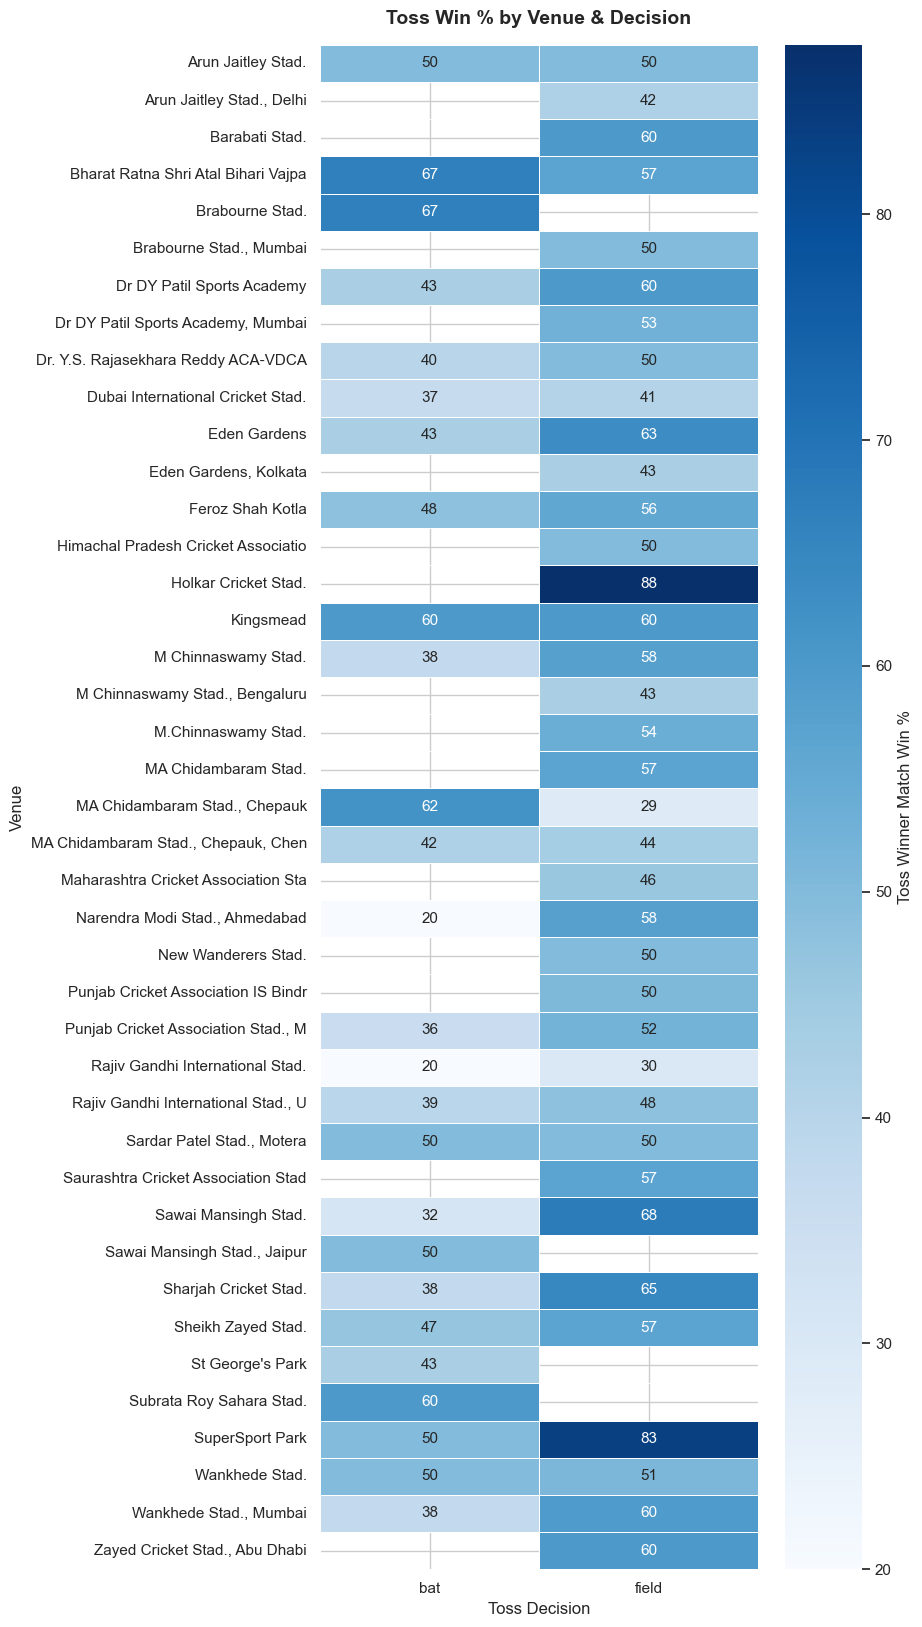

Chart 4 saved: chart4_toss_heatmap.png


In [6]:
q = '''SELECT venue, toss_decision,
    ROUND(SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS win_pct
FROM matches
WHERE winner != 'No Result'
GROUP BY venue, toss_decision
HAVING COUNT(*) >= 5
'''
df4 = pd.read_sql(q, engine)

# Shorten long venue names for readability
df4['venue'] = df4['venue'].str.replace('Stadium', 'Stad.').str[:35]

pivot = df4.pivot_table(index='venue', columns='toss_decision', values='win_pct', aggfunc='mean')

plt.figure(figsize=(9, max(8, len(pivot) * 0.4)))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Toss Winner Match Win %'})
plt.title('Toss Win % by Venue & Decision', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Toss Decision', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/chart4_toss_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved: chart4_toss_heatmap.png')

## Chart 5 — Phase-wise Run Rate Grouped Bar — CORE

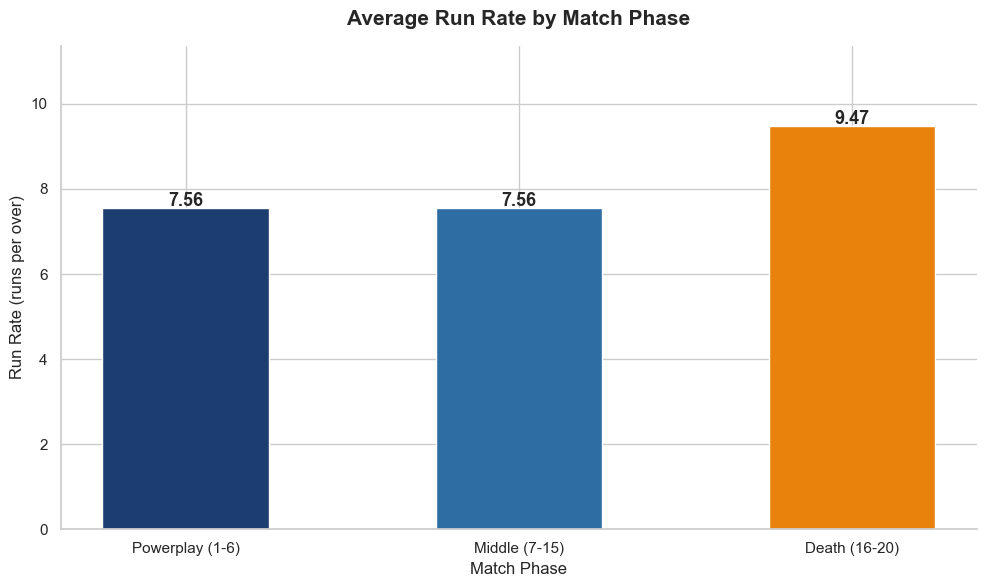

Chart 5 saved: chart5_phase_rr.png


In [7]:
phase_rr = pd.read_csv('../data/processed/phase_run_rate.csv')

# Sort phases in logical order
phase_order = ['Powerplay (1-6)', 'Middle (7-15)', 'Death (16-20)']
phase_rr['phase'] = pd.Categorical(phase_rr['phase'], categories=phase_order, ordered=True)
phase_rr = phase_rr.sort_values('phase')

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [IPL_BLUE, IPL_LIGHT, IPL_ORANGE]
bars = ax.bar(phase_rr['phase'], phase_rr['run_rate'], color=bar_colors,
              edgecolor='white', width=0.5)

for bar, val in zip(bars, phase_rr['run_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontweight='bold', fontsize=13)

ax.set_title('Average Run Rate by Match Phase', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Run Rate (runs per over)', fontsize=12)
ax.set_xlabel('Match Phase', fontsize=12)
ax.set_ylim(0, phase_rr['run_rate'].max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/chart5_phase_rr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved: chart5_phase_rr.png')

## Chart 6 — Strike Rate vs Average Scatter 

In [10]:
q = '''
SELECT batter,
    SUM(batsman_runs) AS total_runs,
    ROUND(AVG(batsman_runs), 2) AS avg_runs,
    ROUND(SUM(batsman_runs)*100.0/COUNT(*), 2) AS strike_rate
FROM deliveries
GROUP BY batter
HAVING SUM(batsman_runs) >= 1000
ORDER BY total_runs DESC
LIMIT 60
'''

df6 = pd.read_sql(q, engine)

fig = px.scatter(
    df6,
    x='avg_runs',
    y='strike_rate',
    size='total_runs',
    hover_data=['batter'],
    text='batter',
    title='Strike Rate vs Average — Top 60 IPL Batsmen (min 1000 runs)',
    color='total_runs',
    color_continuous_scale='Blues',
    labels={'avg_runs': 'Batting Average', 'strike_rate': 'Strike Rate'}
)

fig.update_traces(textposition='top center', textfont_size=8)

fig.update_layout(
    title_font_size=15,
    title_x=0.5,
    plot_bgcolor='white',
    height=600
)

# Quadrant lines
fig.add_hline(y=df6['strike_rate'].median(), line_dash='dash', line_color='gray', opacity=0.5)
fig.add_vline(x=df6['avg_runs'].median(), line_dash='dash', line_color='gray', opacity=0.5)

fig.write_image('../outputs/chart6_sr_vs_avg.png', width=1000, height=650)

fig.show()

print('Chart 6 saved: chart6_sr_vs_avg.png')

Chart 6 saved: chart6_sr_vs_avg.png


## Chart 7 — Season-wise Boundaries 

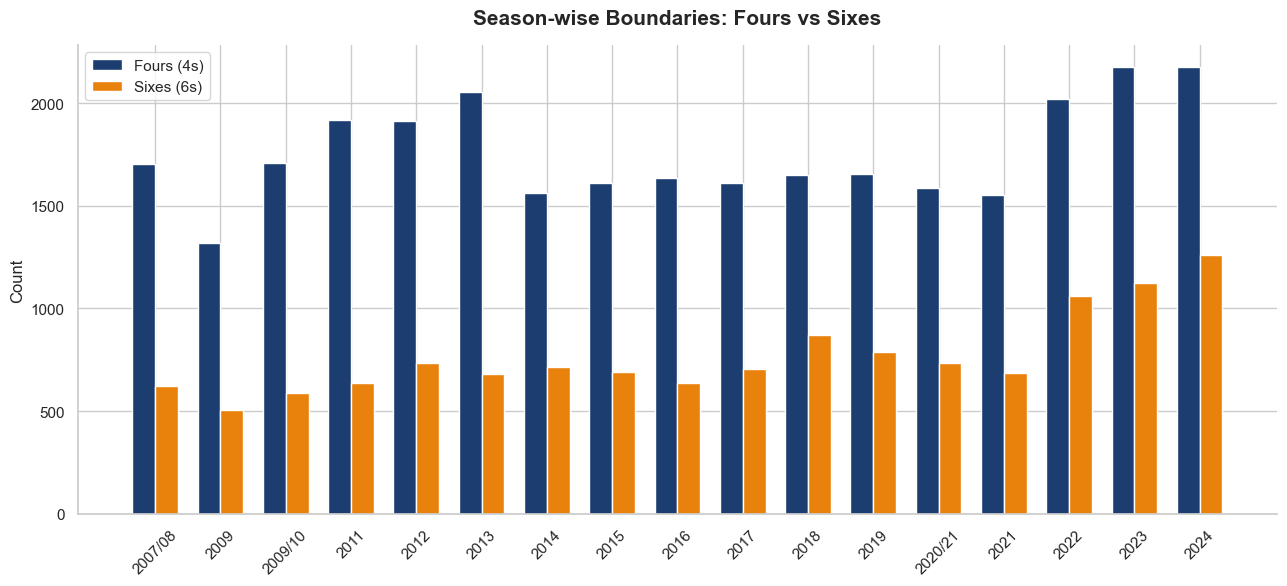

Chart 7 saved: chart7_boundaries.png


In [11]:
q = '''
SELECT m.season,
    SUM(CASE WHEN d.batsman_runs = 4 THEN 1 ELSE 0 END) AS fours,
    SUM(CASE WHEN d.batsman_runs = 6 THEN 1 ELSE 0 END) AS sixes
FROM deliveries d JOIN matches m ON d.match_id = m.match_id
GROUP BY m.season
ORDER BY m.season
'''
df7 = pd.read_sql(q, engine)

fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(df7))
width = 0.35
ax.bar([i - width/2 for i in x], df7['fours'], width, label='Fours (4s)', color=IPL_BLUE)
ax.bar([i + width/2 for i in x], df7['sixes'], width, label='Sixes (6s)', color=IPL_ORANGE)
ax.set_xticks(list(x))
ax.set_xticklabels(df7['season'], rotation=45)
ax.set_title('Season-wise Boundaries: Fours vs Sixes', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Count', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/chart7_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7 saved: chart7_boundaries.png')

## Chart 8 — Top Venues by Average First Innings Score

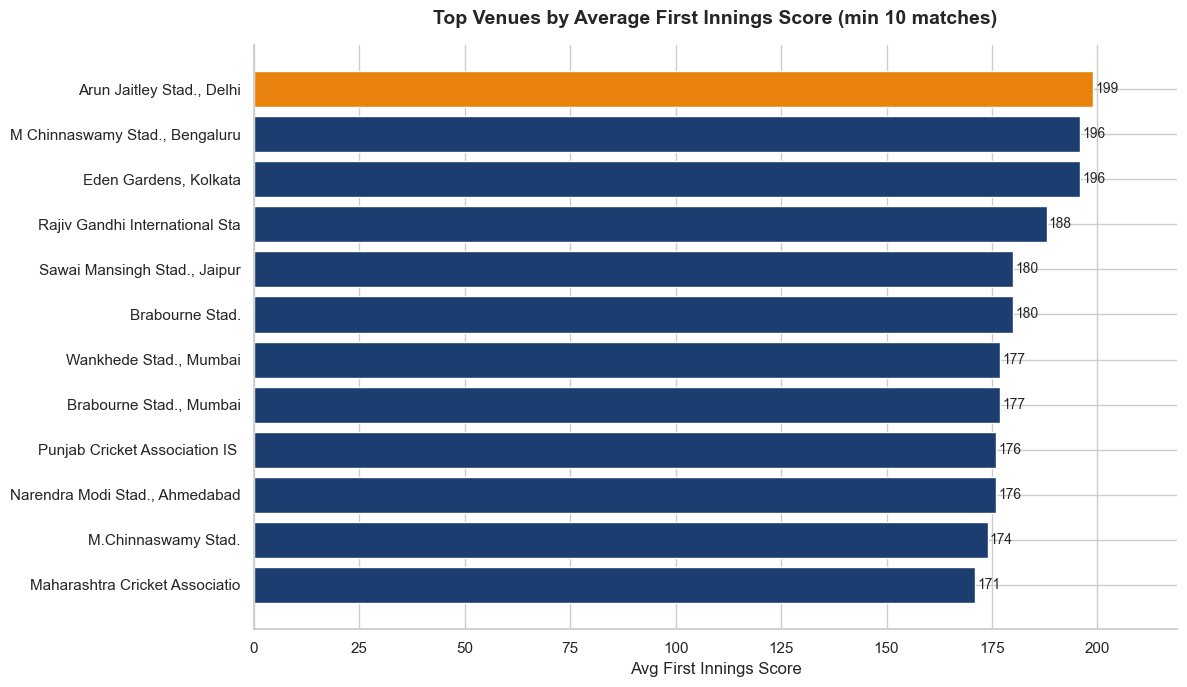

Chart 8 saved: chart8_venue_scores.png


In [12]:
q = '''
SELECT m.venue,
    ROUND(AVG(innings_total), 0) AS avg_first_innings_score,
    COUNT(*) AS matches
FROM (
    SELECT match_id, SUM(total_runs) AS innings_total
    FROM deliveries
    WHERE inning = 1
    GROUP BY match_id
) d JOIN matches m ON d.match_id = m.match_id
GROUP BY m.venue
HAVING matches >= 10
ORDER BY avg_first_innings_score DESC
LIMIT 12
'''
df8 = pd.read_sql(q, engine)
df8['venue_short'] = df8['venue'].str.replace('Stadium', 'Stad.').str[:30]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df8['venue_short'], df8['avg_first_innings_score'],
               color=[IPL_BLUE if i > 0 else IPL_ORANGE for i in range(len(df8))],
               edgecolor='white')

for bar, val in zip(bars, df8['avg_first_innings_score']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(val)}', va='center', fontsize=10)

ax.invert_yaxis()
ax.set_title('Top Venues by Average First Innings Score (min 10 matches)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Avg First Innings Score', fontsize=12)
ax.set_xlim(0, df8['avg_first_innings_score'].max() * 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/chart8_venue_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 8 saved: chart8_venue_scores.png')

In [13]:
import os
charts = [f for f in os.listdir('../outputs') if f.endswith('.png')]
print(f'\n✅ MODULE 2 COMPLETE!')
print(f'{len(charts)} charts saved to outputs/')
for c in sorted(charts):
    print(f'  ✓ {c}')


✅ MODULE 2 COMPLETE!
8 charts saved to outputs/
  ✓ chart1_season_runs.png
  ✓ chart2_top_batsmen.png
  ✓ chart3_wicket_types.png
  ✓ chart4_toss_heatmap.png
  ✓ chart5_phase_rr.png
  ✓ chart6_sr_vs_avg.png
  ✓ chart7_boundaries.png
  ✓ chart8_venue_scores.png


**Outcome:** Generated key charts and saved as PNG to `outputs/` which can be imported in Power BI